In [1]:
# These modules are required for the data reduction.
from dysh.fits.gbtfitsload import GBTFITSLoad
from dysh.log import init_logging
from astropy import units as u
import numpy as np

# This module is used for custom plotting.
import matplotlib.pyplot as plt

# We will use this module to compare with published results.
import pandas as pd

# These modules are used for file I/O
from dysh.util.files import dysh_data
from dysh.util.download import from_url
from pathlib import Path

In [2]:
init_logging(2)

# also create a local "output" directory where temporary notebook files can be stored.
output_dir = Path.cwd() / "output"
output_dir.mkdir(exist_ok=True)

In [3]:
filename = dysh_data(example="survey")

16:02:40.127 I Resolving example=survey -> hi-survey/data/AGBT04A_008_02.raw.acs/AGBT04A_008_02.raw.acs.fits


16:02:40.130 I url: http://www.gb.nrao.edu/dysh//example_data/hi-survey/data/AGBT04A_008_02.raw.acs/AGBT04A_008_02.raw.acs.fits


Odd-1, did not find /bigdisk/data/gbt/dysh_data/example_data/hi-survey/data/AGBT04A_008_02.raw.acs/AGBT04A_008_02.raw.acs.fits
AGBT04A_008_02.raw.acs.fits already downloaded


In [4]:
sdfits = GBTFITSLoad(filename)

In [5]:
sdfits.summary()

SCAN,OBJECT,VELOCITY,PROC,PROCSEQN,RESTFREQ,# IF,# POL,# INT,# FEED,AZIMUTH,ELEVATION
220,3C286,0.0,OffOn,1,1.400000,1,2,6,1,185.2806,82.0246
221,3C286,0.0,OffOn,2,1.400000,1,2,6,1,187.2136,81.9980
222,3C286,0.0,OffOn,1,1.400000,1,2,6,1,193.8331,81.8413
223,3C286,0.0,OffOn,2,1.400000,1,2,6,1,195.6766,81.7788
224,3C286,0.0,OffOn,1,1.400000,1,2,6,1,195.5182,80.2910
225,3C286,0.0,OffOn,2,1.400000,1,2,5,1,199.9358,81.6005
226,3C286,0.0,OffOn,1,1.400000,1,2,6,1,200.8333,80.0265
227,3C286,0.0,OffOn,2,1.400000,1,2,6,1,205.9471,81.2609
228,B1328+254,0.0,OffOn,1,1.400000,1,2,6,1,207.5257,73.9844
229,B1328+254,0.0,OffOn,2,1.400000,1,2,6,1,210.9600,75.1584


In [6]:
tcal = sdfits.gettcal(scan=226, ifnum=0, plnum=0, fdnum=0, zenith_opacity=0.08)

16:02:41.202 I Using Perley-Butler 2017 for 3C286.


16:02:41.205 I Will use getps to calibrate the data.


In [7]:
tcal_0 = tcal.get_tcal()
print(tcal_0)

18.58283


In [8]:
tcal = sdfits.gettcal(scan=226, ifnum=0, plnum=1, fdnum=0, zenith_opacity=0.08)
tcal_1 = tcal.get_tcal()
print(tcal_1)

16:02:43.306 I Using Perley-Butler 2017 for 3C286.


16:02:43.308 I Will use getps to calibrate the data.


21.63284


In [9]:
sdfits.summary(scan=226, add_columns="CALTYPE, TCAL")

SCAN,OBJECT,VELOCITY,PROC,PROCSEQN,RESTFREQ,# IF,# POL,# INT,# FEED,AZIMUTH,ELEVATION,CALTYPE,TCAL
226,3C286,0.0,OffOn,1,1.4,1,2,6,1,200.8333,80.0265,HIGH,21.317758


In [10]:
sdfits.summary(add_columns="CALTYPE")

SCAN,OBJECT,VELOCITY,PROC,PROCSEQN,RESTFREQ,# IF,# POL,# INT,# FEED,AZIMUTH,ELEVATION,CALTYPE
220,3C286,0.0,OffOn,1,1.400000,1,2,6,1,185.2806,82.0246,HIGH
221,3C286,0.0,OffOn,2,1.400000,1,2,6,1,187.2136,81.9980,HIGH
222,3C286,0.0,OffOn,1,1.400000,1,2,6,1,193.8331,81.8413,HIGH
223,3C286,0.0,OffOn,2,1.400000,1,2,6,1,195.6766,81.7788,HIGH
224,3C286,0.0,OffOn,1,1.400000,1,2,6,1,195.5182,80.2910,HIGH
225,3C286,0.0,OffOn,2,1.400000,1,2,5,1,199.9358,81.6005,HIGH
226,3C286,0.0,OffOn,1,1.400000,1,2,6,1,200.8333,80.0265,HIGH
227,3C286,0.0,OffOn,2,1.400000,1,2,6,1,205.9471,81.2609,HIGH
228,B1328+254,0.0,OffOn,1,1.400000,1,2,6,1,207.5257,73.9844,HIGH
229,B1328+254,0.0,OffOn,2,1.400000,1,2,6,1,210.9600,75.1584,HIGH


In [11]:
sdfits.index().loc[sdfits["PLNUM"] == 0, "TCAL"] = tcal_0
sdfits.index().loc[sdfits["PLNUM"] == 1, "TCAL"] = tcal_1

In [12]:
sdfits["TCAL"][ (sdfits["SCAN"] == 226) & (sdfits["PLNUM"] == 0) ], tcal_0

(142    18.58283
 143    18.58283
 146    18.58283
 147    18.58283
 150    18.58283
 151    18.58283
 154    18.58283
 155    18.58283
 158    18.58283
 159    18.58283
 162    18.58283
 163    18.58283
 Name: TCAL, dtype: float32,
 np.float32(18.58283))

In [13]:
sdfits["TCAL"][ (sdfits["SCAN"] == 226) & (sdfits["PLNUM"] == 1) ], tcal_1

(140    21.632839
 141    21.632839
 144    21.632839
 145    21.632839
 148    21.632839
 149    21.632839
 152    21.632839
 153    21.632839
 156    21.632839
 157    21.632839
 160    21.632839
 161    21.632839
 Name: TCAL, dtype: float32,
 np.float32(21.63284))

In [14]:
pssb0 = sdfits.getps(scan=270, plnum=0, ifnum=0, fdnum=0)
pssb0

ScanBlock([PSScan scan=271 ifnum=0 (rest freq=1.42 GHz) plnum=0 (YY) fdnum=0 source='U8503'])

In [15]:
pssb0[0].tsys

array([23.15395387, 23.15939981, 23.1696684 , 23.14617098, 23.16118822,
       23.16688336, 23.15221981, 23.14632482, 23.13719172, 23.1660217 ,
       23.16490218, 23.16024192, 23.15046162, 23.1557475 , 23.15496778,
       23.15356847, 23.15246949, 23.15252061, 23.18794126, 23.16724025,
       23.16009429, 23.14933254, 23.15150266, 23.15174903, 23.15595792,
       23.15470471, 23.15362478, 23.18724805, 23.15418276, 23.15090147])

In [16]:
pssb0[0].exposure

array([4.77948809, 4.77948809, 4.77948809, 4.77948809, 4.77948809,
       4.77948809, 4.77948809, 4.77948809, 4.77948809, 4.77948797,
       4.77948809, 4.77948809, 4.77948809, 4.77948809, 4.77948809,
       4.77948809, 4.77948809, 4.77948809, 4.77948785, 4.77948809,
       4.77948809, 4.77948809, 4.77948809, 4.77948809, 4.77948809,
       4.77948809, 4.77948809, 4.77948797, 4.77948797, 4.77948809])

In [17]:
pssb0[0].scan

271

In [18]:
pssb0[0].plnum

0

In [19]:
pssb0[0].ifnum

0

In [20]:
pssb0[0].calibrated

masked_array(
  data=[[-42.95573792102767, -14.786980497120691, 50.680546568201024,
         ..., -0.04795008242404048, 0.05551870961717607,
         0.46735376850896293],
        [20.79514890484046, -28.012823791386825, -0.16838359164340005,
         ..., 0.24525655427112789, 0.5678707470489164,
         1.4632634154078992],
        [0.9344087650459408, -17.416289751211536, 5.172508938594352, ...,
         0.16856129404589837, 0.8176920712587327, 0.30326067864391515],
        ...,
        [40.22337015566295, -24.03132518007429, -19.72912609017763, ...,
         -0.755331043339712, -0.25957163363582336, -1.8308870748472765],
        [-126.5365640563671, 39.916026838756395, -42.40570781831775, ...,
         0.021537792127780498, 0.5424438514917936, 0.39256936524051056],
        [-11.247179829074131, 41.47191291388775, -15.084885206981554,
         ..., -0.7265820800954403, -0.4581267483859805,
         0.16670335471984124]],
  mask=[[False, False, False, ..., False, False, False],
     

In [21]:
pssb0_int0 = pssb0[0].getspec(0)
pssb0_int0

<Spectrum(flux=[-42.95573792102767 ... 0.46735376850896293] K (shape=(32768,), mean=0.00758 K); spectral_axis=<SpectralAxis 
   (observer: <ITRS Coordinate (obstime=2004-04-22T07:08:15.000, location=(0.0, 0.0, 0.0) km): (x, y, z) in m
                  (882593.9465029, -4924896.36541728, 3943748.74743984)
               (v_x, v_y, v_z) in km / s
                  (0., 0., 0.)>
    target: <SkyCoord (FK5: equinox=J2000.000): (ra, dec, distance) in (deg, deg, kpc)
                (202.68562135, 32.76085866, 1000000.)
             (pm_ra_cosdec, pm_dec, radial_velocity) in (mas / yr, mas / yr, km / s)
                (0., 0., 4676.)>
    observer to target (computed from above):
      radial_velocity=4686.132814909312 km / s
      redshift=0.0157553569969906
    doppler_rest=1420405400.0 Hz
    doppler_convention=optical)
  [1.39229407e+09 1.39229445e+09 1.39229483e+09 ... 1.40479293e+09
 1.40479331e+09 1.40479369e+09] Hz> (length=32768))>

/bigdisk/src/dysh/.venv/lib/python3.12/site-packages/numpy/lib/_function_base_impl.py:2599: RuntimeWarning: invalid value encountered in do_format (vectorized)
  outputs = ufunc(*args, out=...)


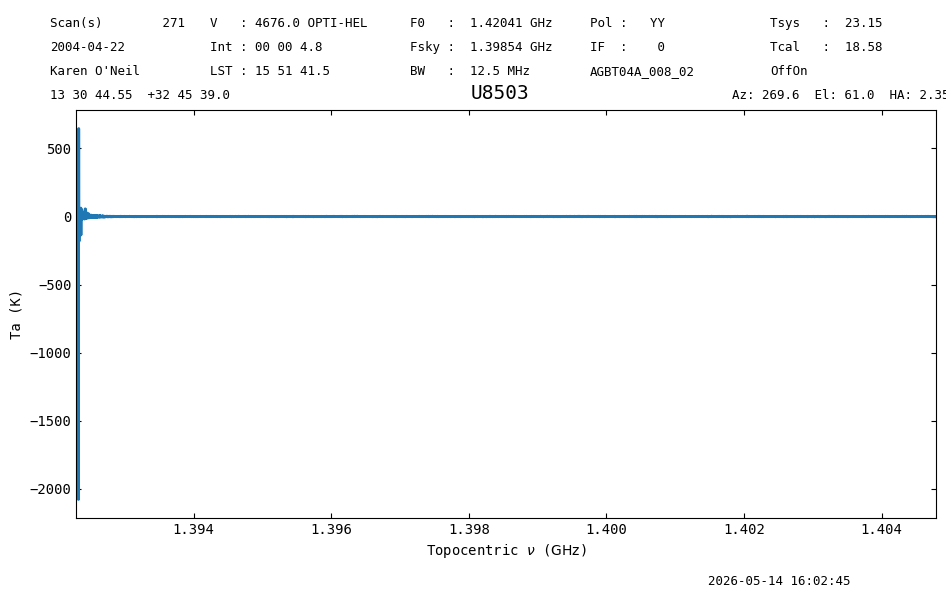

In [22]:
pssb0_int0.plot();

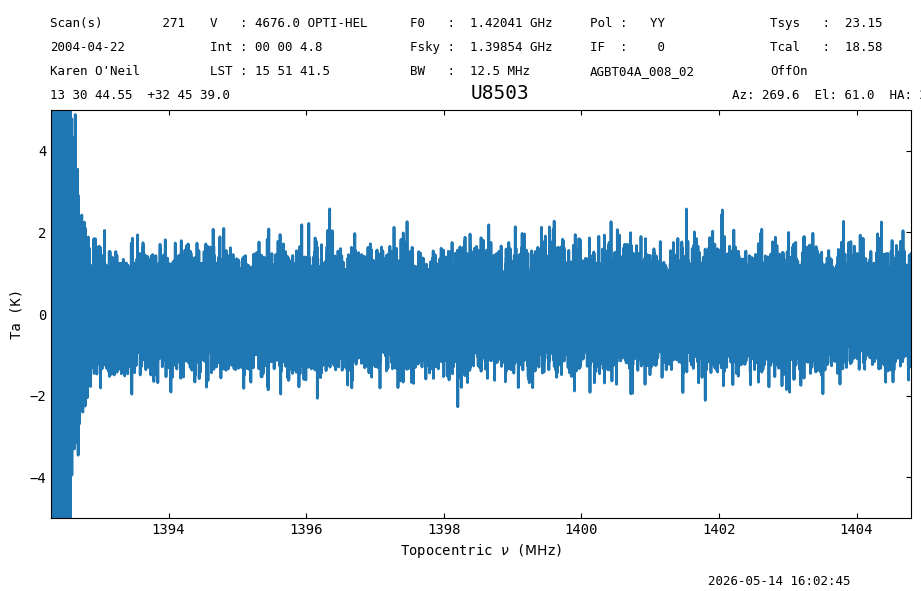

In [23]:
pssb0_int0.plot(ymin=-5, ymax=5, xaxis_unit = "MHz");

In [24]:
ps0_spec = pssb0.timeaverage()
ps0_spec

<Spectrum(flux=[-17.518453828552644 ... 0.05390234844823292] K (shape=(32768,), mean=0.13130 K); spectral_axis=<SpectralAxis 
   (observer: <ITRS Coordinate (obstime=2004-04-22T07:08:15.000, location=(0.0, 0.0, 0.0) km): (x, y, z) in m
                  (882593.9465029, -4924896.36541728, 3943748.74743984)
               (v_x, v_y, v_z) in km / s
                  (0., 0., 0.)>
    target: <SkyCoord (FK5: equinox=J2000.000): (ra, dec, distance) in (deg, deg, kpc)
                (202.68562135, 32.76085866, 1000000.)
             (pm_ra_cosdec, pm_dec, radial_velocity) in (mas / yr, mas / yr, km / s)
                (0., 0., 4676.)>
    observer to target (computed from above):
      radial_velocity=4686.132814909312 km / s
      redshift=0.0157553569969906
    doppler_rest=1420405400.0 Hz
    doppler_convention=optical)
  [1.39229407e+09 1.39229445e+09 1.39229483e+09 ... 1.40479293e+09
 1.40479331e+09 1.40479369e+09] Hz> (length=32768))>

/bigdisk/src/dysh/.venv/lib/python3.12/site-packages/numpy/lib/_function_base_impl.py:2599: RuntimeWarning: invalid value encountered in do_format (vectorized)
  outputs = ufunc(*args, out=...)


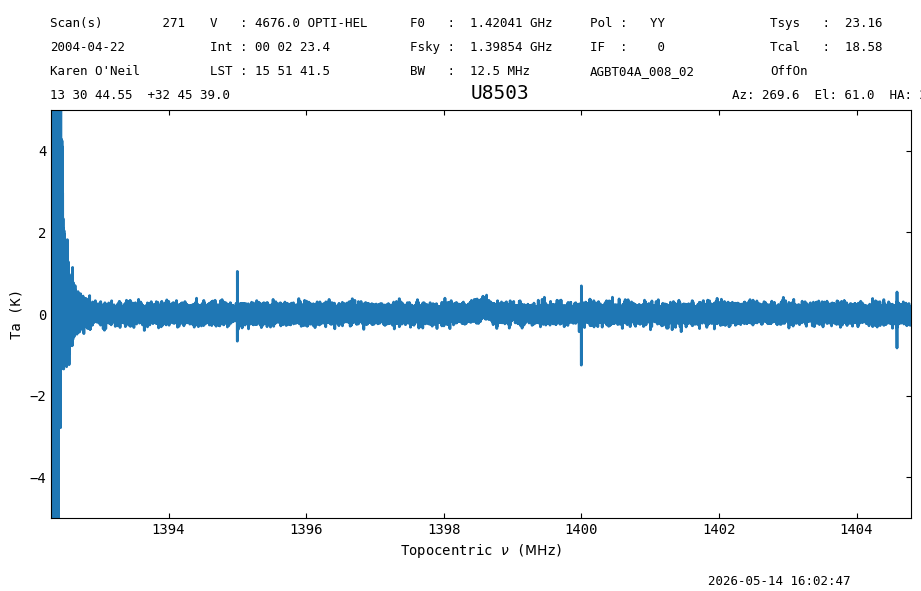

In [25]:
ps0_spec.plot(ymin=-5, ymax=5, xaxis_unit = "MHz");

In [26]:
ps0_spec_smo = ps0_spec.smooth("gauss", 16)

/bigdisk/src/dysh/.venv/lib/python3.12/site-packages/numpy/lib/_function_base_impl.py:2599: RuntimeWarning: invalid value encountered in do_format (vectorized)
  outputs = ufunc(*args, out=...)


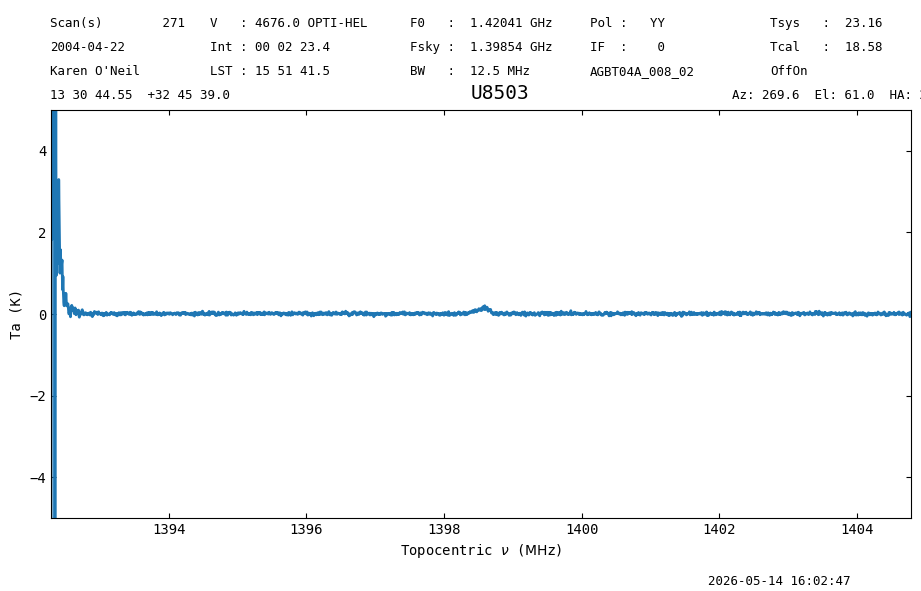

In [27]:
ps0_spec_smo.plot(ymin=-5, ymax=5, xaxis_unit = "MHz");

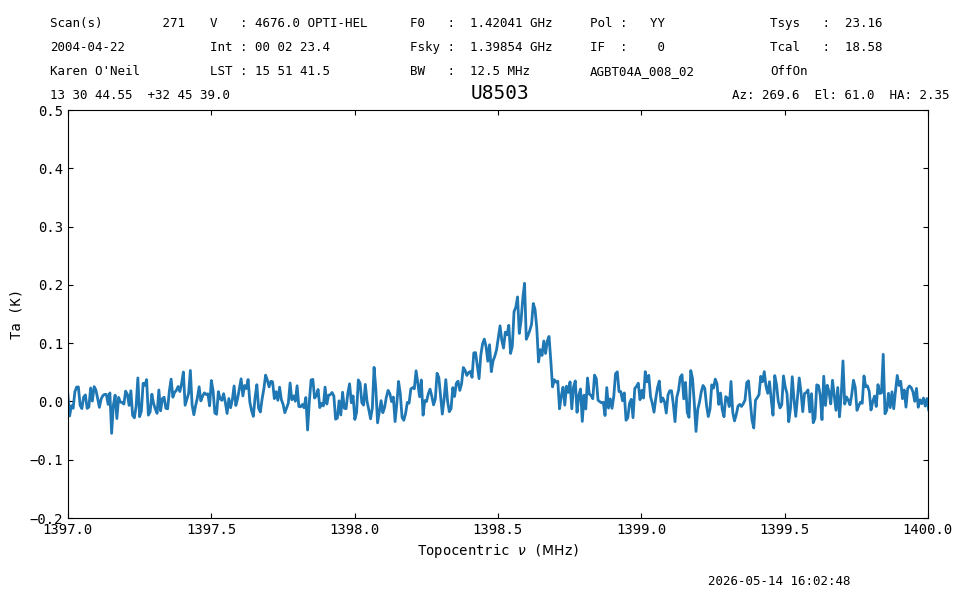

In [28]:
ps0_spec_smo.plot(ymin=-0.2, ymax=0.5, xmin=1397, xmax=1400, xaxis_unit = "MHz");

In [29]:
ps1_spec_smo = sdfits.getps(scan=270, plnum=1, ifnum=0, fdnum=0).timeaverage().smooth("gauss", 16)

/bigdisk/src/dysh/.venv/lib/python3.12/site-packages/numpy/lib/_function_base_impl.py:2599: RuntimeWarning: invalid value encountered in do_format (vectorized)
  outputs = ufunc(*args, out=...)


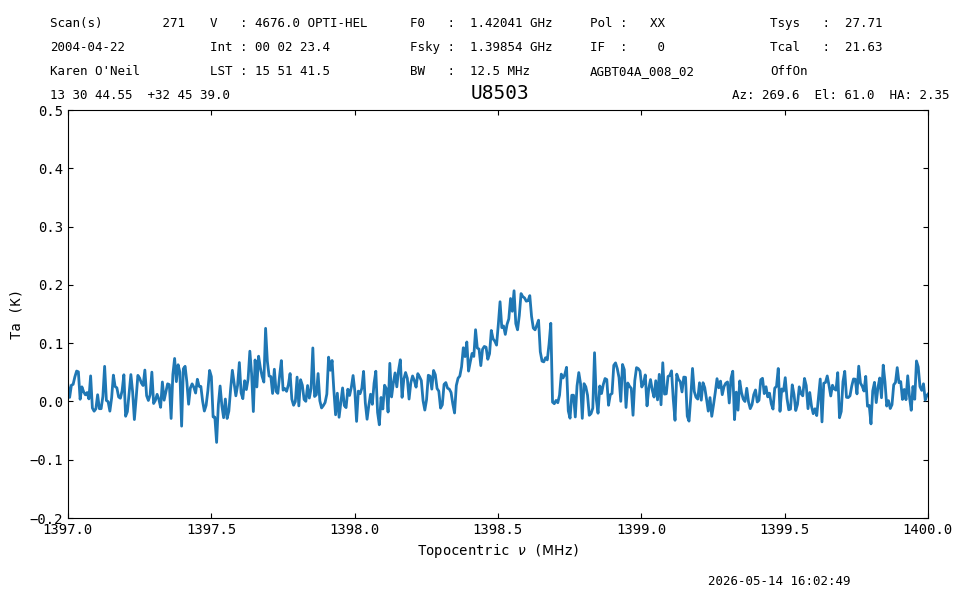

In [30]:
ps1_spec_smo.plot(ymin=-0.2, ymax=0.5, xmin=1397, xmax=1400, xaxis_unit = "MHz");

In [31]:
ps_spec_smo = ps0_spec_smo.average([ps1_spec_smo])

/bigdisk/src/dysh/.venv/lib/python3.12/site-packages/numpy/lib/_function_base_impl.py:2599: RuntimeWarning: invalid value encountered in do_format (vectorized)
  outputs = ufunc(*args, out=...)


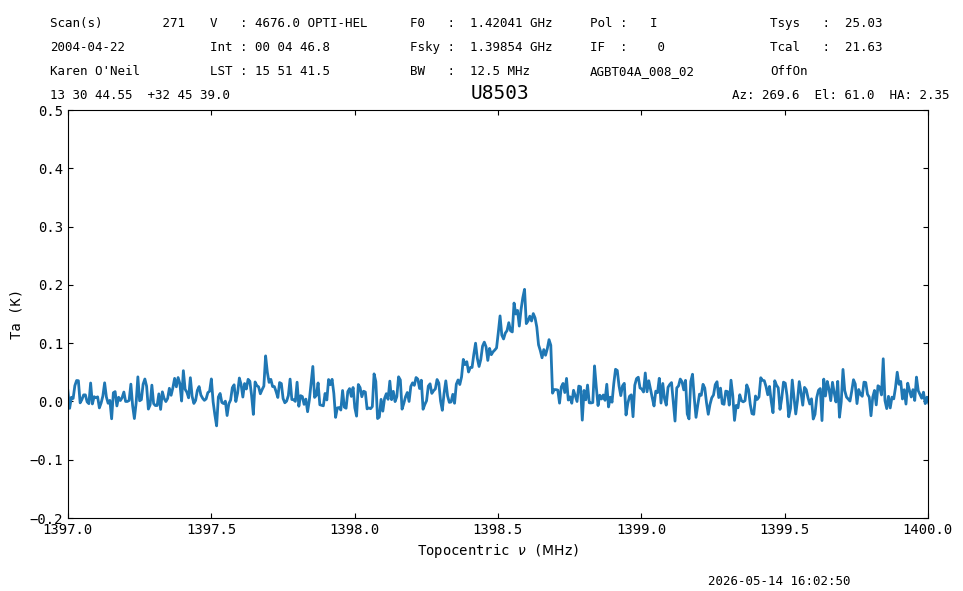

In [32]:
ps_spec_smo.plot(ymin=-0.2, ymax=0.5, xmin=1397, xmax=1400, xaxis_unit = "MHz");

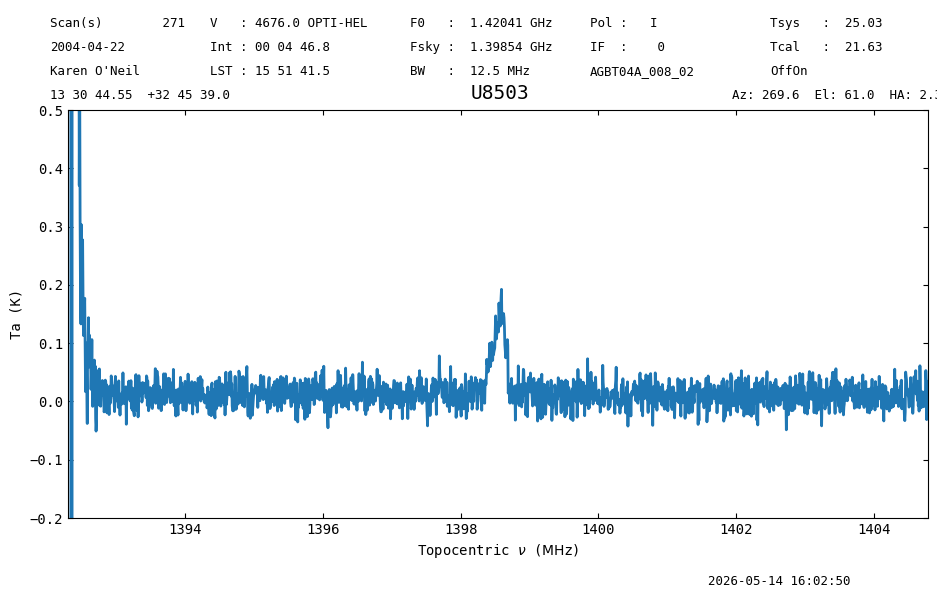

In [33]:
ps_spec_smo.plotter.reset()
ps_spec_smo.plot(ymin=-0.2, ymax=0.5, xaxis_unit = "MHz");

In [34]:
s = slice(1394*u.MHz, 1398*u.MHz)
ps_spec_smo[s].stats()   # rms 0.02056197 K

{'mean': <Quantity 0.01239604 K>,
 'median': <Quantity 0.01256029 K>,
 'rms': <Quantity 0.01864966 K>,
 'min': <Quantity -0.04519255 K>,
 'max': <Quantity 0.07814448 K>,
 'npt': 656,
 'nan': np.int64(0)}

In [35]:
ps0_spec_smo[s].stats(), ps1_spec_smo[s].stats()

({'mean': <Quantity 0.0081166 K>,
  'median': <Quantity 0.00727765 K>,
  'rms': <Quantity 0.02144106 K>,
  'min': <Quantity -0.06647171 K>,
  'max': <Quantity 0.06994961 K>,
  'npt': 656,
  'nan': np.int64(0)},
 {'mean': <Quantity 0.01852274 K>,
  'median': <Quantity 0.01722145 K>,
  'rms': <Quantity 0.0269218 K>,
  'min': <Quantity -0.07031096 K>,
  'max': <Quantity 0.12539079 K>,
  'npt': 656,
  'nan': np.int64(0)})

16:02:53.811 I 1000000000.0 Hz is below the minimum spectral axis 1392294069.4697266 Hz. Replacing.


/bigdisk/src/dysh/.venv/lib/python3.12/site-packages/numpy/lib/_function_base_impl.py:2599: RuntimeWarning: invalid value encountered in do_format (vectorized)
  outputs = ufunc(*args, out=...)


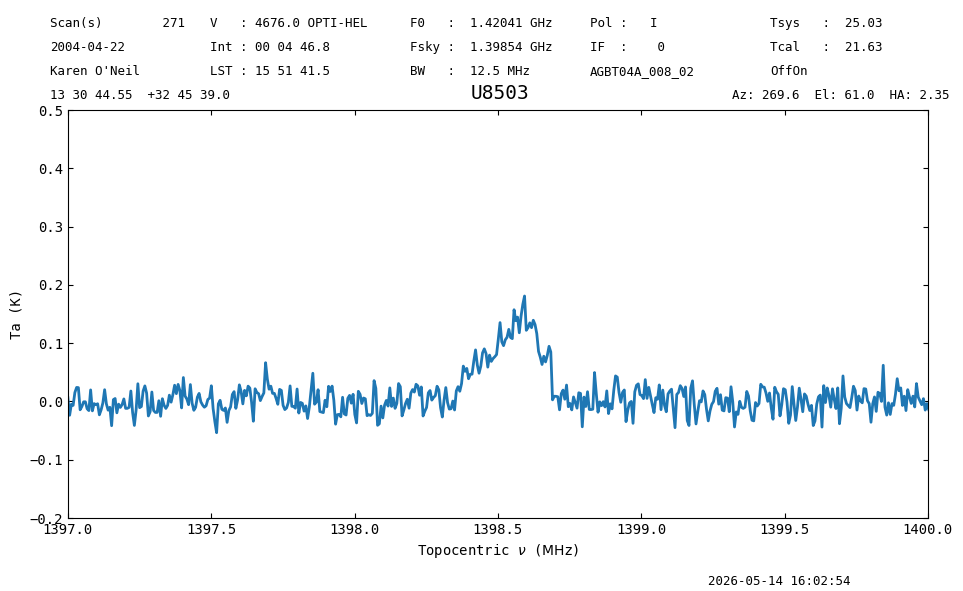

In [36]:
exclude = [(1*u.GHz,1.394*u.GHz),(1.398*u.GHz,1.4*u.GHz)]
ps_spec_smo.baseline(1, model="poly", exclude=exclude, remove=True)
ps_spec_smo.plot(ymin=-0.2, ymax=0.5, xmin=1397, xmax=1400, xaxis_unit = "MHz");

In [37]:
ps_spec_smo[s].stats()  # rms 0.02056173 K

{'mean': <Quantity 0.00025023 K>,
 'median': <Quantity 0.00030788 K>,
 'rms': <Quantity 0.01864944 K>,
 'min': <Quantity -0.05731845 K>,
 'max': <Quantity 0.06644079 K>,
 'npt': 656,
 'nan': np.int64(0)}

/bigdisk/src/dysh/.venv/lib/python3.12/site-packages/numpy/lib/_function_base_impl.py:2599: RuntimeWarning: invalid value encountered in do_format (vectorized)
  outputs = ufunc(*args, out=...)


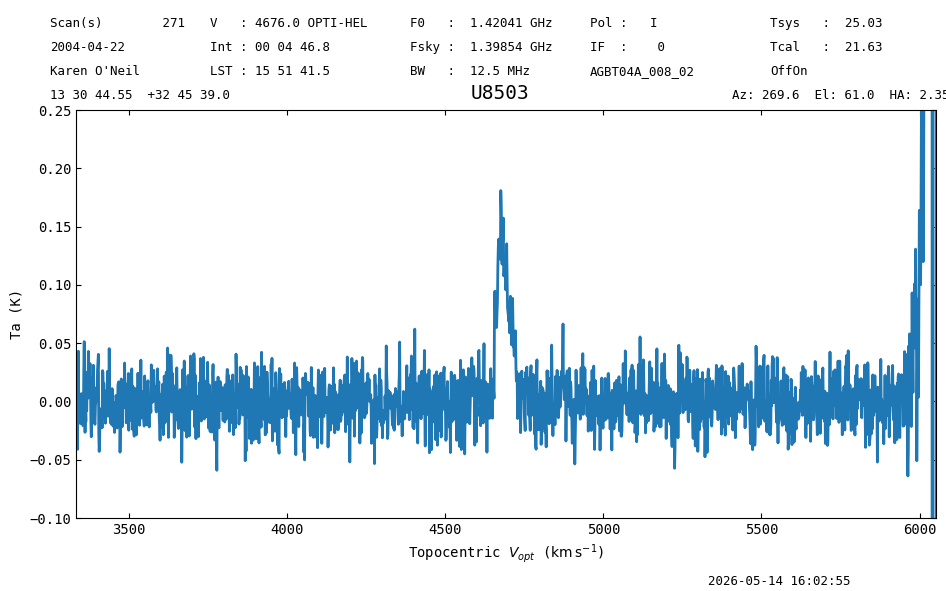

In [38]:
ps_spec_smo.plot(ymax=0.25, ymin=-0.1, xaxis_unit="km/s");

In [39]:
scan_list = list(set(sdfits["SCAN"][(sdfits["OBJECT"] == "3C286") & \
                     (sdfits["PROC"] == "OffOn") & (sdfits["CAL"] == "T")]))
sorted(scan_list)

[220, 221, 222, 223, 224, 225, 226, 227]

In [40]:
ps0_obj = sdfits.getps(scan=scan_list, plnum=0, ifnum=0, fdnum=0).timeaverage()
ps1_obj = sdfits.getps(scan=scan_list, plnum=1, ifnum=0, fdnum=0).timeaverage()
ps_obj = ps0_obj.average(ps1_obj);

/bigdisk/src/dysh/.venv/lib/python3.12/site-packages/numpy/lib/_function_base_impl.py:2599: RuntimeWarning: invalid value encountered in do_format (vectorized)
  outputs = ufunc(*args, out=...)


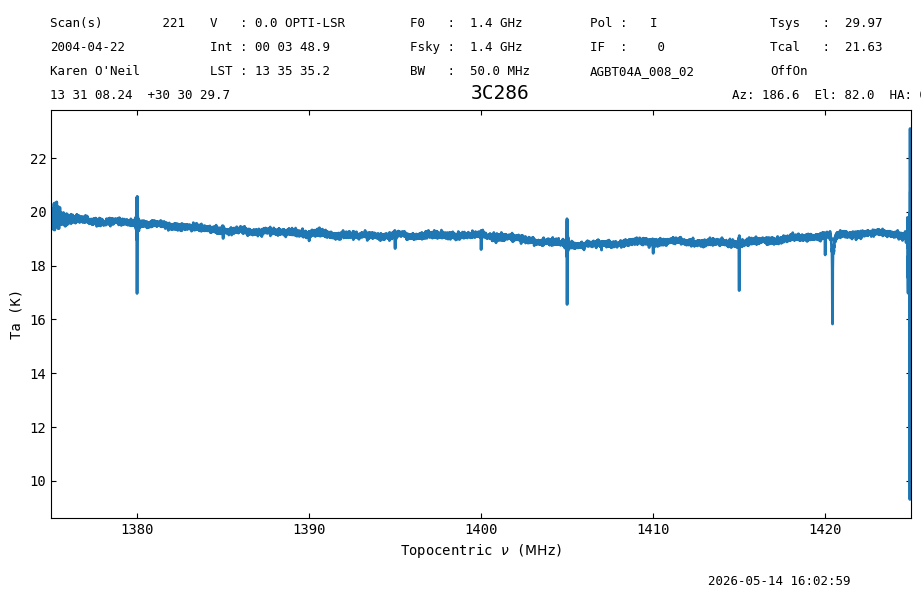

In [41]:
ps_obj.plot(xaxis_unit = "MHz");

/bigdisk/src/dysh/.venv/lib/python3.12/site-packages/numpy/lib/_function_base_impl.py:2599: RuntimeWarning: invalid value encountered in do_format (vectorized)
  outputs = ufunc(*args, out=...)


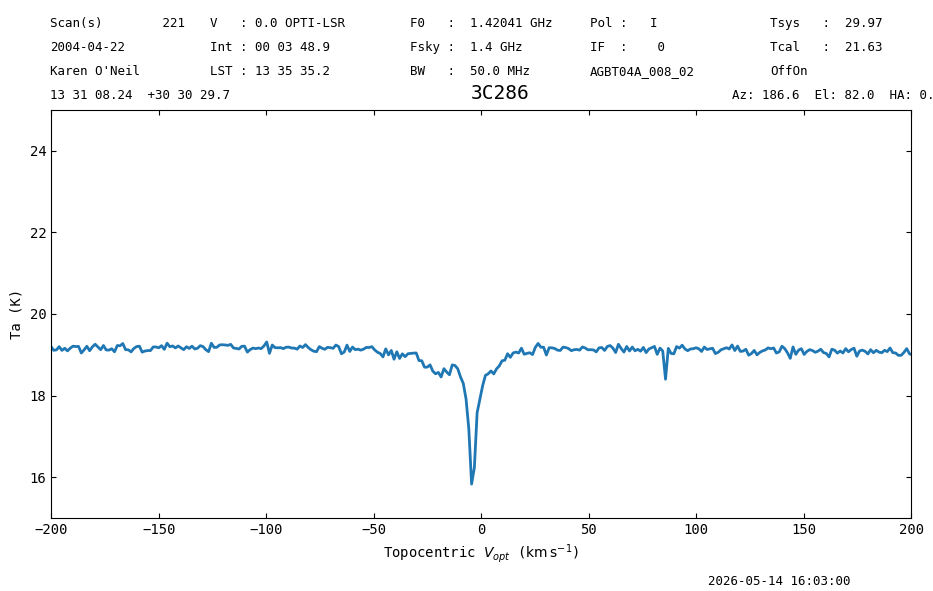

In [42]:
ps_obj.rest_value = 1420405751.786 * u.Hz
ps_obj.plot(xmin=-200, xmax=200, ymin=15, ymax=25, xaxis_unit="km/s");

In [43]:
sdfits.select(object="3C286", proc="OffOn")
ps0_obj_b = sdfits.getps(plnum=0, ifnum=0, fdnum=0).timeaverage()
ps1_obj_b = sdfits.getps(plnum=1, ifnum=0, fdnum=0).timeaverage()
ps_obj_b = ps0_obj_b.average(ps1_obj_b)

/bigdisk/src/dysh/.venv/lib/python3.12/site-packages/numpy/lib/_function_base_impl.py:2599: RuntimeWarning: invalid value encountered in do_format (vectorized)
  outputs = ufunc(*args, out=...)


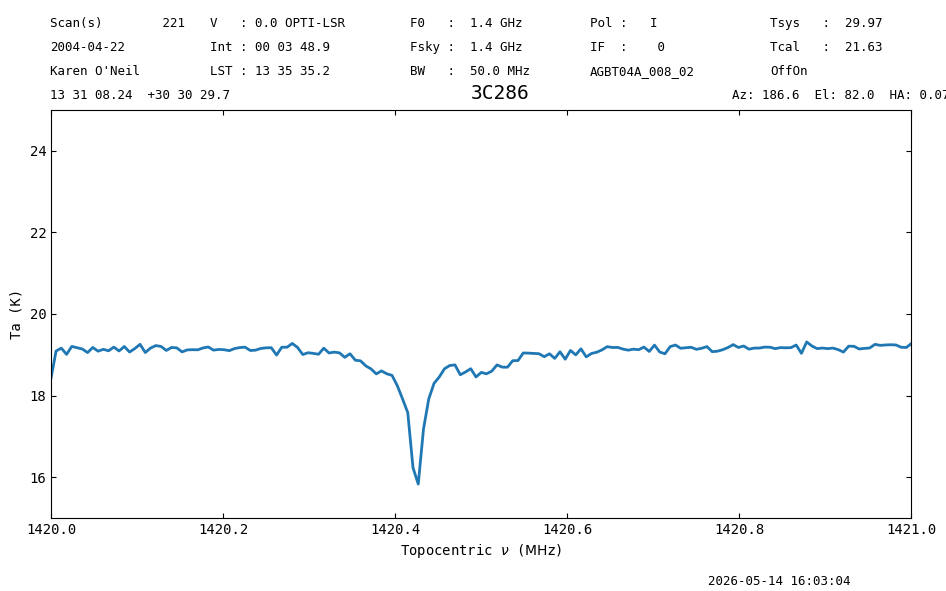

In [44]:
ps_obj_b.plot(xmin=1420, xmax=1421, ymin=15, ymax=25, xaxis_unit = "MHz");

In [45]:
sdfits.selection.clear()

16:03:04.534 W Scan 266 has no matching ON scan. Will not calibrate.


16:03:04.761 I No data found for scan(s) [228, 229, 230, 231, 244, 245, 246, 247, 248, 249, 250, 251, 263, 264, 265, 266, 267, 268, 269, 270, 271, 272, 273, 274, 275, 276, 277, 278, 279, 280, 281, 282, 283, 284, 285, 286, 287, 288, 289, 290, 291, 292, 293, 294, 295, 296, 297, 298, 299, 300, 301, 302, 303, 304, 305, 306, 307, 308, 309, 310, 311, 312, 313, 314, 315, 316, 317, 318, 319, 320, 321, 322, 323] with the given selection criteria.
Available parameters for those scans:
Scan 228: ifnum=[0] plnum=[0, 1] fdnum=[0]
Scan 229: ifnum=[0] plnum=[0, 1] fdnum=[0]
Scan 230: ifnum=[0] plnum=[0, 1] fdnum=[0]
Scan 231: ifnum=[0] plnum=[0, 1] fdnum=[0]
Scan 244: ifnum=[0] plnum=[0, 1] fdnum=[0]
Scan 245: ifnum=[0] plnum=[0, 1] fdnum=[0]
Scan 246: ifnum=[0] plnum=[0, 1] fdnum=[0]
Scan 247: ifnum=[0] plnum=[0, 1] fdnum=[0]
Scan 248: ifnum=[0] plnum=[0, 1] fdnum=[0]
Scan 249: ifnum=[0] plnum=[0, 1] fdnum=[0]
Scan 250: ifnum=[0] plnum=[0, 1] fdnum=[0]
Scan 251: ifnum=[0] plnum=[0, 1] fdnum=[0]
Scan

16:03:06.322 W Scan 266 has no matching ON scan. Will not calibrate.


16:03:06.542 I No data found for scan(s) [228, 229, 230, 231, 244, 245, 246, 247, 248, 249, 250, 251, 263, 264, 265, 266, 267, 268, 269, 270, 271, 272, 273, 274, 275, 276, 277, 278, 279, 280, 281, 282, 283, 284, 285, 286, 287, 288, 289, 290, 291, 292, 293, 294, 295, 296, 297, 298, 299, 300, 301, 302, 303, 304, 305, 306, 307, 308, 309, 310, 311, 312, 313, 314, 315, 316, 317, 318, 319, 320, 321, 322, 323] with the given selection criteria.
Available parameters for those scans:
Scan 228: ifnum=[0] plnum=[0, 1] fdnum=[0]
Scan 229: ifnum=[0] plnum=[0, 1] fdnum=[0]
Scan 230: ifnum=[0] plnum=[0, 1] fdnum=[0]
Scan 231: ifnum=[0] plnum=[0, 1] fdnum=[0]
Scan 244: ifnum=[0] plnum=[0, 1] fdnum=[0]
Scan 245: ifnum=[0] plnum=[0, 1] fdnum=[0]
Scan 246: ifnum=[0] plnum=[0, 1] fdnum=[0]
Scan 247: ifnum=[0] plnum=[0, 1] fdnum=[0]
Scan 248: ifnum=[0] plnum=[0, 1] fdnum=[0]
Scan 249: ifnum=[0] plnum=[0, 1] fdnum=[0]
Scan 250: ifnum=[0] plnum=[0, 1] fdnum=[0]
Scan 251: ifnum=[0] plnum=[0, 1] fdnum=[0]
Scan

/bigdisk/src/dysh/.venv/lib/python3.12/site-packages/numpy/lib/_function_base_impl.py:2599: RuntimeWarning: invalid value encountered in do_format (vectorized)
  outputs = ufunc(*args, out=...)


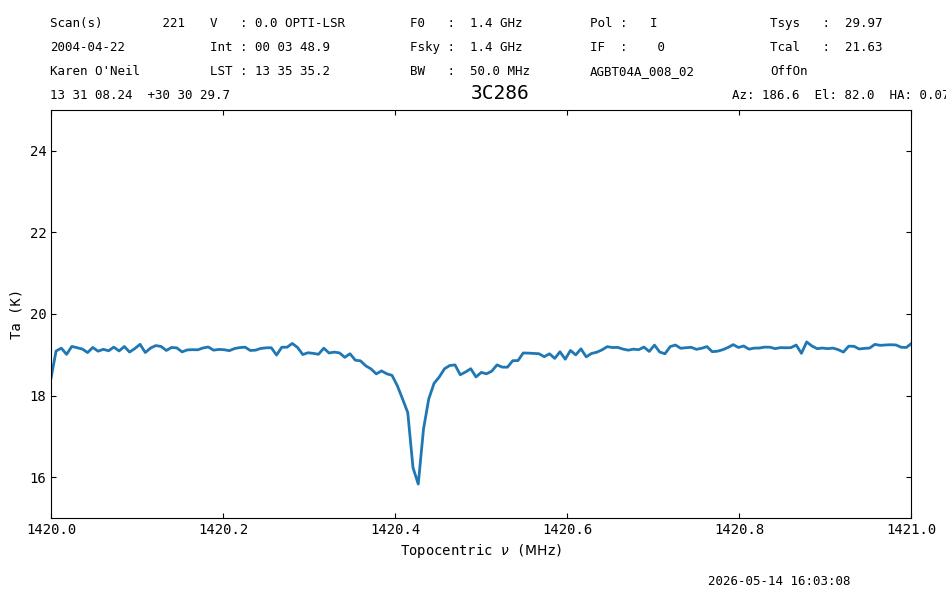

In [46]:
ps0_obj_c = sdfits.getps(plnum=0, ifnum=0, fdnum=0, object="3C286", proc="OffOn").timeaverage()
ps1_obj_c = sdfits.getps(plnum=1, ifnum=0, fdnum=0, object="3C286", proc="OffOn").timeaverage()
ps_obj_c = ps0_obj_c.average(ps1_obj_c)
ps_obj_c.plot(xmin=1420, xmax=1421, ymin=15, ymax=25, xaxis_unit = "MHz");

In [47]:
tp0 = sdfits.gettp(scan=320, plnum=0, ifnum=0, fdnum=0).timeaverage()
tp1 = sdfits.gettp(scan=320, plnum=1, ifnum=0, fdnum=0).timeaverage()

In [48]:
print(f"System temperature for plnum={tp0.meta['PLNUM']}: {tp0.meta['TSYS']:.2f} K")
print(f"System temperature for plnum={tp1.meta['PLNUM']}: {tp1.meta['TSYS']:.2f} K")

System temperature for plnum=0: 23.88 K
System temperature for plnum=1: 28.39 K


In [49]:
sdfits.select(object="U11627", proc="OffOn")
ps0_wtsys = sdfits.getps(plnum=0, ifnum=0, fdnum=0, t_sys=tp0.meta['TSYS']).timeaverage()
ps1_wtsys = sdfits.getps(plnum=1, ifnum=0, fdnum=0, t_sys=tp1.meta['TSYS']).timeaverage()
ps_wtsys = ps0_wtsys.average(ps1_wtsys)

16:03:12.027 I Ignoring 2 blanked integration(s).


In [50]:
s = slice(1392.5*u.MHz, 1394.9*u.MHz)
ps_wtsys[s].radiometer()

np.float64(1.0060377308633648)

/bigdisk/src/dysh/.venv/lib/python3.12/site-packages/numpy/lib/_function_base_impl.py:2599: RuntimeWarning: invalid value encountered in do_format (vectorized)
  outputs = ufunc(*args, out=...)


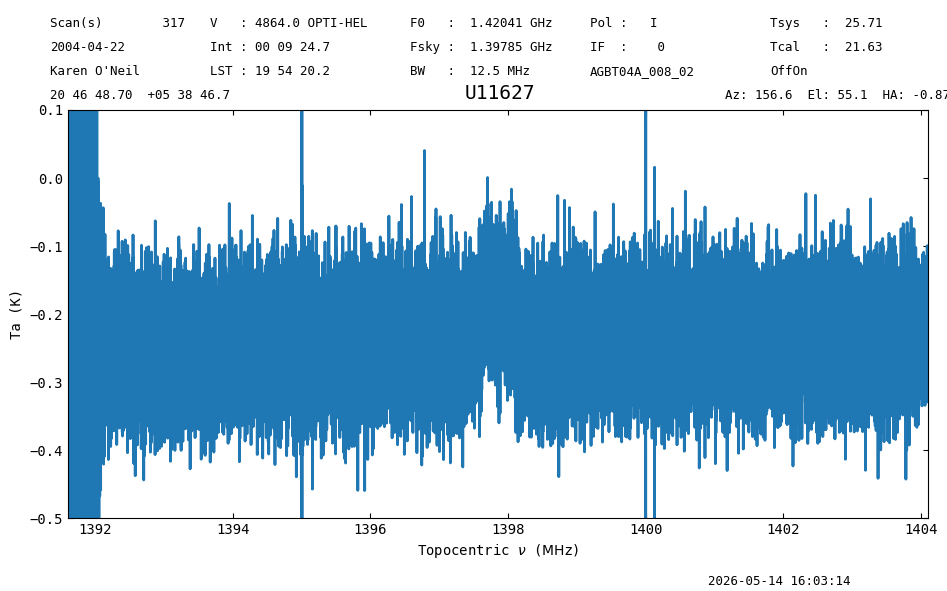

In [51]:
ps_wtsys.plot(ymin=-0.5, ymax=0.1, xaxis_unit = "MHz");

In [52]:
ps_wtsys_smo = ps_wtsys.smooth("gauss", 16)
ps_wtsys_smo.baseline(1, model="poly", exclude=[(1*u.GHz,1.393*u.GHz),(1.397*u.GHz,1.399*u.GHz)], remove=True)

16:03:15.249 I 1000000000.0 Hz is below the minimum spectral axis 1391602258.4697266 Hz. Replacing.


/bigdisk/src/dysh/.venv/lib/python3.12/site-packages/numpy/lib/_function_base_impl.py:2599: RuntimeWarning: invalid value encountered in do_format (vectorized)
  outputs = ufunc(*args, out=...)


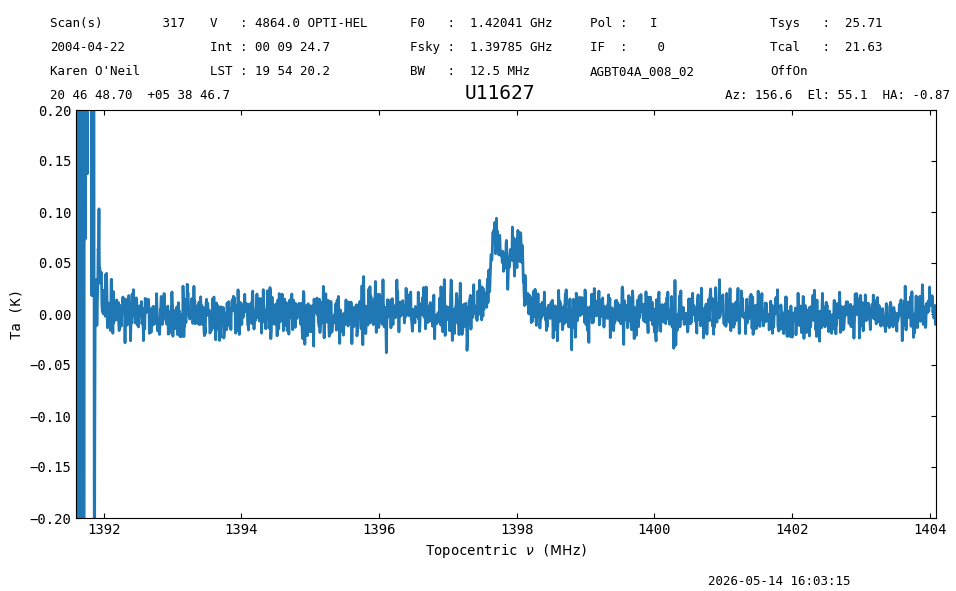

In [53]:
ps_wtsys_smo.plot(ymin=-0.2, ymax=0.2, xaxis_unit = "MHz");

In [54]:
sdfits.selection.clear()

In [55]:
tp_ref0 = sdfits.gettp(scan=[316,318], plnum=0, ifnum=0, fdnum=0, t_sys=tp0.meta['TSYS']).timeaverage()
tp_ref1 = sdfits.gettp(scan=[316,318], plnum=1, ifnum=0, fdnum=0, t_sys=tp1.meta['TSYS']).timeaverage()

In [56]:
sdfits.select(object="U11627", proc="OffOn")
ps0_wtsys_tpr = sdfits.getsigref(scan=[317,319], ref=tp_ref0, plnum=0, ifnum=0, fdnum=0).timeaverage()
ps1_wtsys_tpr = sdfits.getsigref(scan=[317,319], ref=tp_ref1, plnum=1, ifnum=0, fdnum=0).timeaverage()

16:03:20.069 I Ignoring 2 blanked integration(s).


In [57]:
ps_wtsys_tpr = ps0_wtsys_tpr.average(ps1_wtsys_tpr)
ps_wtsys_tpr_smo = ps_wtsys_tpr.smooth("gauss", 16)
ps_wtsys_tpr_smo.baseline(1, model="poly", 
                          exclude=[(1*u.GHz,1.393*u.GHz),(1.397*u.GHz,1.399*u.GHz)], 
                          remove=True)

16:03:21.808 I 1000000000.0 Hz is below the minimum spectral axis 1391602258.4697266 Hz. Replacing.


/bigdisk/src/dysh/.venv/lib/python3.12/site-packages/numpy/lib/_function_base_impl.py:2599: RuntimeWarning: invalid value encountered in do_format (vectorized)
  outputs = ufunc(*args, out=...)


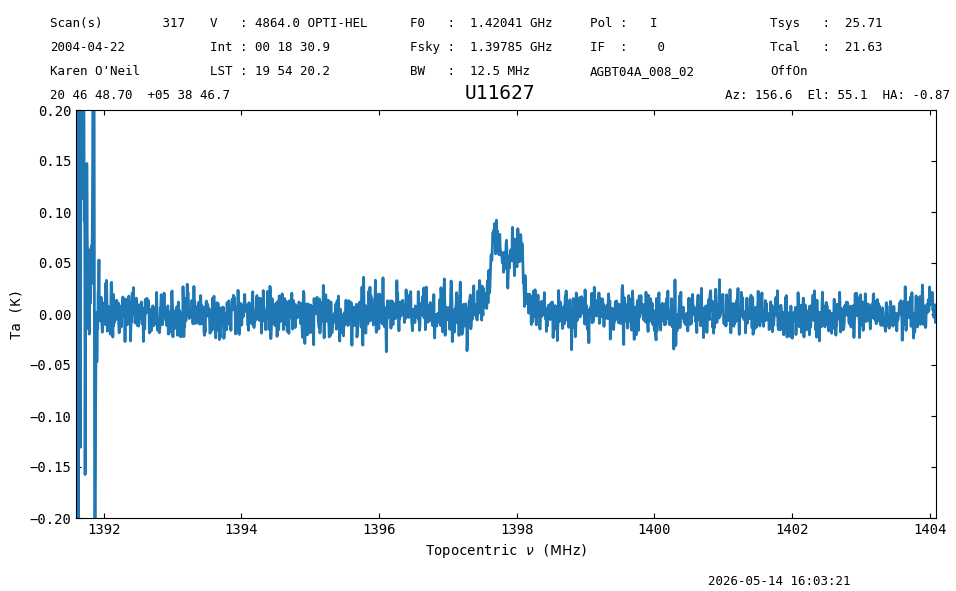

In [58]:
ps_wtsys_tpr_smo.plot(ymin=-0.2, ymax=0.2, xaxis_unit = "MHz");

In [59]:
s = slice(1.393*u.GHz, 1.396*u.GHz)
rms_tpr = ps_wtsys_tpr_smo[s].stats()["rms"]
rms = ps_wtsys_smo[s].stats()["rms"]
print(f"Ratio of rms: {rms_tpr/rms}")

Ratio of rms: 0.9999915516119442


16:03:26.171 I Ignoring 2 blanked integration(s).


16:03:27.674 I 1000000000.0 Hz is below the minimum spectral axis 1391602258.4697266 Hz. Replacing.


/bigdisk/src/dysh/.venv/lib/python3.12/site-packages/numpy/lib/_function_base_impl.py:2599: RuntimeWarning: invalid value encountered in do_format (vectorized)
  outputs = ufunc(*args, out=...)


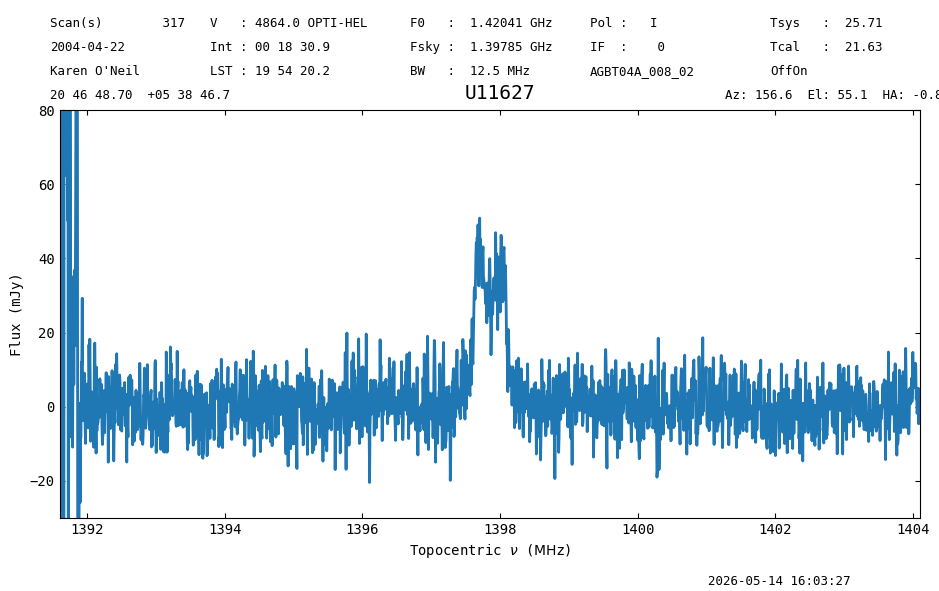

In [60]:
ps0_wtsys_tpr = sdfits.getsigref(scan=[317,319], ref=tp_ref0, plnum=0, ifnum=0, fdnum=0, 
                                 units="flux", zenith_opacity=0.08).timeaverage()
ps1_wtsys_tpr = sdfits.getsigref(scan=[317,319], ref=tp_ref1, plnum=1, ifnum=0, fdnum=0, 
                                 units="flux", zenith_opacity=0.08).timeaverage()
ps_wtsys_tpr = ps0_wtsys_tpr.average(ps1_wtsys_tpr)
ps_wtsys_tpr_smo = ps_wtsys_tpr.smooth("gauss", 16)
ps_wtsys_tpr_smo.baseline(1, model="poly", 
                          exclude=[(1*u.GHz,1.393*u.GHz),(1.397*u.GHz,1.399*u.GHz)], 
                          remove=True)
ps_wtsys_tpr_smo.plot(ymin=-30, ymax=80, yaxis_unit="mJy", xaxis_unit = "MHz");

In [61]:
line_props = ps_wtsys_tpr_smo[60:-60].cog()
line_props

16:03:28.303 I Velocity frame: Topocentric


16:03:28.306 I Doppler convention: optical


{'flux': <Quantity 4.6089158 Jy km / s>,
 'flux_std': <Quantity 0.3167822 Jy km / s>,
 'flux_r': <Quantity 0.54153427 Jy km / s>,
 'flux_r_std': <Quantity 0.17333814 Jy km / s>,
 'flux_b': <Quantity 4.00106748 Jy km / s>,
 'flux_b_std': <Quantity 0.21254396 Jy km / s>,
 'width': {0.25: <Quantity 49.23181793 km / s>,
  0.65: <Quantity 155.67900098 km / s>,
  0.75: <Quantity 182.29080043 km / s>,
  0.85: <Quantity 208.90260197 km / s>,
  0.95: <Quantity 246.15912821 km / s>},
 'width_std': {0.25: <Quantity 5.34507999 km / s>,
  0.65: <Quantity 10.75795749 km / s>,
  0.75: <Quantity 13.43018918 km / s>,
  0.85: <Quantity 34.65836073 km / s>,
  0.95: <Quantity 18.7902007 km / s>},
 'A_F': np.float64(7.388392022857113),
 'A_C': np.float64(3.5634034906080134),
 'C_V': np.float64(4.243243714231644),
 'rms': <Quantity 0.0063105 Jy>,
 'bchan': np.int64(738),
 'echan': np.int64(1108),
 'vel': <Quantity 4891.74433254 km / s>,
 'vel_std': <Quantity 600.6873799 km / s>,
 'vframe': 'itrs',
 'doppler

/bigdisk/src/dysh/.venv/lib/python3.12/site-packages/traitlets/traitlets.py:1385: DeprecationWarning: Passing unrecognized arguments to super(Toolbar).__init__().
NavigationToolbar2WebAgg.__init__() missing 1 required positional argument: 'canvas'
This is deprecated in traitlets 4.2.This error will be raised in a future release of traitlets.
  warn(


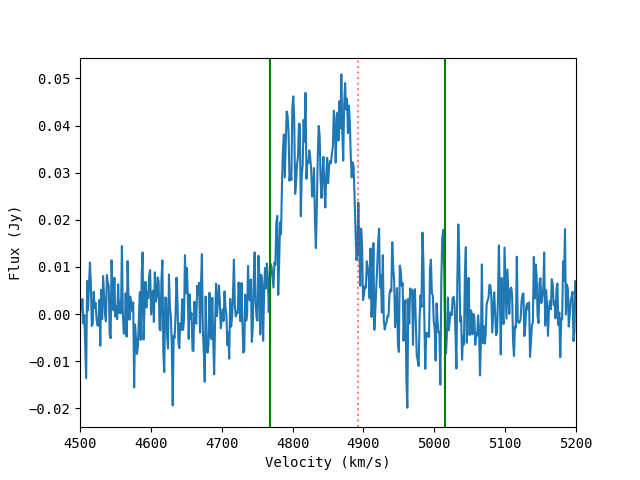

In [62]:
plt.figure()
plt.plot(ps_wtsys_tpr_smo[60:].spectral_axis.to("km/s"), ps_wtsys_tpr_smo[60:].flux)
plt.axvline(line_props["vel"].value, c="r", alpha=0.5, ls=":")
plt.axvline((line_props["vel"] - line_props["width"][0.95]/2).value, c="g")
plt.axvline((line_props["vel"] + line_props["width"][0.95]/2).value, c="g")
plt.xlim(4500, 5200)
plt.xlabel("Velocity (km/s)")
plt.ylabel("Flux (Jy)")
plt.show()

In [63]:
line_props_wrange = ps_wtsys_tpr_smo[60:-60].cog(bchan=line_props["bchan"], echan=line_props["echan"])
line_props_wrange

16:03:28.892 I Velocity frame: Topocentric


16:03:28.893 I Doppler convention: optical


{'flux': <Quantity 4.29035597 Jy km / s>,
 'flux_std': <Quantity 0.04635971 Jy km / s>,
 'flux_r': <Quantity 2.36095971 Jy km / s>,
 'flux_r_std': <Quantity 0.07150743 Jy km / s>,
 'flux_b': <Quantity 1.93023937 Jy km / s>,
 'flux_b_std': <Quantity 0.06158165 Jy km / s>,
 'width': {0.25: <Quantity 33.25196154 km / s>,
  0.65: <Quantity 81.13478735 km / s>,
  0.75: <Quantity 91.77541565 km / s>,
  0.85: <Quantity 107.73635843 km / s>,
  0.95: <Quantity 158.27934713 km / s>},
 'width_std': {0.25: <Quantity 1.36866178 km / s>,
  0.65: <Quantity 1.55611853 km / s>,
  0.75: <Quantity 1.61419184 km / s>,
  0.85: <Quantity 2.87004329 km / s>,
  0.95: <Quantity 8.13591869 km / s>},
 'A_F': np.float64(1.2231434838173203),
 'A_C': np.float64(1.0623088645068575),
 'C_V': np.float64(3.2400000916666984),
 'rms': <Quantity 0.0063105 Jy>,
 'bchan': np.int64(738),
 'echan': np.int64(1108),
 'vel': <Quantity 4833.02529707 km / s>,
 'vel_std': <Quantity 248.5201989 km / s>,
 'vframe': 'itrs',
 'doppler_

In [64]:
line_props_wrange = ps_wtsys_tpr_smo[60:-60].cog(bchan=750, echan=1100)
line_props_wrange

16:03:29.053 I Velocity frame: Topocentric


16:03:29.054 I Doppler convention: optical


{'flux': <Quantity 4.2852502 Jy km / s>,
 'flux_std': <Quantity 0.04769484 Jy km / s>,
 'flux_r': <Quantity 2.30771859 Jy km / s>,
 'flux_r_std': <Quantity 0.08347333 Jy km / s>,
 'flux_b': <Quantity 1.97590404 Jy km / s>,
 'flux_b_std': <Quantity 0.0684514 Jy km / s>,
 'width': {0.25: <Quantity 33.2525423 km / s>,
  0.65: <Quantity 81.1362044 km / s>,
  0.75: <Quantity 91.77701855 km / s>,
  0.85: <Quantity 107.73824009 km / s>,
  0.95: <Quantity 155.62190763 km / s>},
 'width_std': {0.25: <Quantity 2.68090569 km / s>,
  0.65: <Quantity 1.55624457 km / s>,
  0.75: <Quantity 2.81406913 km / s>,
  0.85: <Quantity 2.87009341 km / s>,
  0.95: <Quantity 10.75401215 km / s>},
 'A_F': np.float64(1.167930500459024),
 'A_C': np.float64(1.0831728945459125),
 'C_V': np.float64(3.2400000916621514),
 'rms': <Quantity 0.00629814 Jy>,
 'bchan': np.int64(750),
 'echan': np.int64(1100),
 'vel': <Quantity 4835.71979288 km / s>,
 'vel_std': <Quantity 244.6108976 km / s>,
 'vframe': 'itrs',
 'doppler_con

/bigdisk/src/dysh/.venv/lib/python3.12/site-packages/traitlets/traitlets.py:1385: DeprecationWarning: Passing unrecognized arguments to super(Toolbar).__init__().
NavigationToolbar2WebAgg.__init__() missing 1 required positional argument: 'canvas'
This is deprecated in traitlets 4.2.This error will be raised in a future release of traitlets.
  warn(


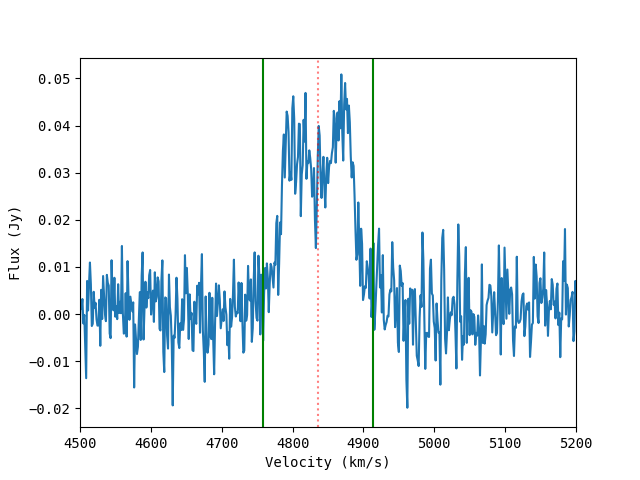

In [65]:
plt.figure()
plt.plot(ps_wtsys_tpr_smo[60:].spectral_axis.to("km/s"), ps_wtsys_tpr_smo[60:].flux)
plt.axvline(line_props_wrange["vel"].value, c="r", alpha=0.5, ls=":")
plt.axvline((line_props_wrange["vel"] - line_props_wrange["width"][0.95]/2).value, c="g")
plt.axvline((line_props_wrange["vel"] + line_props_wrange["width"][0.95]/2).value, c="g")
plt.xlim(4500, 5200)
plt.xlabel("Velocity (km/s)")
plt.ylabel("Flux (Jy)")
plt.show()

In [66]:
def process(sdfits, object, results, track=True):
    """
    Function to calibrate the AGBT04A_008_02 observations.
    This function was heavily tailored to work with this
    observations and there is no guarantee it would work with
    other data.
    """
    
    o = object

    if track:
        # Use only the last Track observation for every object.
        tp0 = sdfits.gettp(ifnum=0, plnum=0, fdnum=0, object=o, proc="Track")[-1].timeaverage()
        tp1 = sdfits.gettp(ifnum=0, plnum=1, fdnum=0, object=o, proc="Track")[-1].timeaverage()
    
        # Calibrate using the system temperature of the Track scan.
        ps0 = sdfits.getps(ifnum=0, plnum=0, fdnum=0, object=o, proc="OffOn", 
                           t_sys=tp0.meta["TSYS"], units="flux", zenith_opacity=0.08).timeaverage()
        ps1 = sdfits.getps(ifnum=0, plnum=1, fdnum=0, object=o, proc="OffOn", 
                           t_sys=tp1.meta["TSYS"], units="flux", zenith_opacity=0.08).timeaverage()

    else:
        # Calibrate computing the system temperature from the Off scan.
        ps0 = sdfits.getps(ifnum=0, plnum=0, fdnum=0, object=o, proc="OffOn", 
                           units="flux", zenith_opacity=0.08).timeaverage()
        ps1 = sdfits.getps(ifnum=0, plnum=1, fdnum=0, object=o, proc="OffOn", 
                           units="flux", zenith_opacity=0.08).timeaverage()

    # Average polarizations.
    ps = ps0.average(ps1)

    # Smooth.
    ps_smo = ps.smooth("gauss", 16)

    # Determine if the Galactic HI line is present, and if so,
    # ignore it during the baseline fit.
    idx0 = np.argmin(abs(ps_smo.spectral_axis - 1.420*u.GHz))
    idxf = np.argmin(abs(ps_smo.spectral_axis - 1.421*u.GHz))
    idx0,idxf = np.sort([idx0,idxf])
    if idx0 == 0 or idx0 == len(ps_smo.data) - 1 or idxf == 0 or idxf == len(ps_smo.data) - 1:
        exclude=[(0,100),(500,1250),(2047-100,2047)]
    else:
        exclude=[(0,100),(500,1250),(idx0,idxf),(2047-100,2047)]

    # Baseline subtraction.
    ps_smo.baseline(degree=1, model="poly", exclude=exclude, remove=True)

    # Measure line properties using Curve of Growth.
    # Ignore 100 channels in each edge, and compute the
    # CoG over the inner (750,1250) channels.
    cog = ps_smo[100:-100].cog(bchan=750, echan=1250, width_frac=[0.95])

    # Save the measured line properties.
    # In particular, the object name, flux and its width.
    results["name"].append(o.replace("U", "UGC "))
    for k in ["flux", "flux_error"]:
        results[k].append(cog[k.replace("error", "std")].to("Jy km/s").value)
    for k in ["width", "width_error"]:
        results[k].append(cog[k.replace("error", "std")][0.95].to("km/s").value)

measured = {"name": [],
            "flux": [],
            "flux_error": [],
            "width": [],
            "width_error": [],
           }

sdfits.selection.clear()
# Start at object 4 since the previous ones were calibration observations.
for o in sdfits.udata("OBJECT")[4:]:

    if o ==  "U8503":
        track = False
    else:
        track = True
    
    process(sdfits, o, measured, track=track)


16:03:29.926 I No data found for scan(s) [220, 221, 222, 223, 224, 225, 226, 227, 228, 229, 230, 231, 244, 245, 246, 247, 248, 249, 250, 251, 263, 264, 265, 266, 267, 268, 270, 271, 272, 273, 274, 275, 276, 278, 279, 280, 281, 282, 283, 284, 285, 286, 287, 288, 289, 290, 291, 292, 293, 294, 295, 296, 297, 298, 299, 300, 301, 302, 303, 304, 305, 306, 307, 308, 309, 310, 311, 312, 313, 314, 315, 316, 317, 318, 319, 320, 321, 322, 323] with the given selection criteria.
Available parameters for those scans:
Scan 220: ifnum=[0] plnum=[0, 1] fdnum=[0]
Scan 221: ifnum=[0] plnum=[0, 1] fdnum=[0]
Scan 222: ifnum=[0] plnum=[0, 1] fdnum=[0]
Scan 223: ifnum=[0] plnum=[0, 1] fdnum=[0]
Scan 224: ifnum=[0] plnum=[0, 1] fdnum=[0]
Scan 225: ifnum=[0] plnum=[0, 1] fdnum=[0]
Scan 226: ifnum=[0] plnum=[0, 1] fdnum=[0]
Scan 227: ifnum=[0] plnum=[0, 1] fdnum=[0]
Scan 228: ifnum=[0] plnum=[0, 1] fdnum=[0]
Scan 229: ifnum=[0] plnum=[0, 1] fdnum=[0]
Scan 230: ifnum=[0] plnum=[0, 1] fdnum=[0]
Scan 231: ifnum=[

16:03:31.785 I No data found for scan(s) [220, 221, 222, 223, 224, 225, 226, 227, 228, 229, 230, 231, 244, 245, 246, 247, 248, 249, 250, 251, 263, 264, 265, 266, 267, 268, 270, 271, 272, 273, 274, 275, 276, 278, 279, 280, 281, 282, 283, 284, 285, 286, 287, 288, 289, 290, 291, 292, 293, 294, 295, 296, 297, 298, 299, 300, 301, 302, 303, 304, 305, 306, 307, 308, 309, 310, 311, 312, 313, 314, 315, 316, 317, 318, 319, 320, 321, 322, 323] with the given selection criteria.
Available parameters for those scans:
Scan 220: ifnum=[0] plnum=[0, 1] fdnum=[0]
Scan 221: ifnum=[0] plnum=[0, 1] fdnum=[0]
Scan 222: ifnum=[0] plnum=[0, 1] fdnum=[0]
Scan 223: ifnum=[0] plnum=[0, 1] fdnum=[0]
Scan 224: ifnum=[0] plnum=[0, 1] fdnum=[0]
Scan 225: ifnum=[0] plnum=[0, 1] fdnum=[0]
Scan 226: ifnum=[0] plnum=[0, 1] fdnum=[0]
Scan 227: ifnum=[0] plnum=[0, 1] fdnum=[0]
Scan 228: ifnum=[0] plnum=[0, 1] fdnum=[0]
Scan 229: ifnum=[0] plnum=[0, 1] fdnum=[0]
Scan 230: ifnum=[0] plnum=[0, 1] fdnum=[0]
Scan 231: ifnum=[

16:03:32.982 W Scan 266 has no matching ON scan. Will not calibrate.


16:03:33.263 I No data found for scan(s) [220, 221, 222, 223, 224, 225, 226, 227, 228, 229, 230, 231, 244, 245, 246, 247, 248, 249, 250, 251, 263, 264, 265, 266, 269, 270, 271, 272, 273, 274, 277, 278, 279, 280, 281, 282, 283, 284, 285, 286, 287, 288, 289, 290, 291, 292, 293, 294, 295, 296, 297, 298, 299, 300, 301, 302, 303, 304, 305, 306, 307, 308, 309, 310, 311, 312, 313, 314, 315, 316, 317, 318, 319, 320, 321, 322, 323] with the given selection criteria.
Available parameters for those scans:
Scan 220: ifnum=[0] plnum=[0, 1] fdnum=[0]
Scan 221: ifnum=[0] plnum=[0, 1] fdnum=[0]
Scan 222: ifnum=[0] plnum=[0, 1] fdnum=[0]
Scan 223: ifnum=[0] plnum=[0, 1] fdnum=[0]
Scan 224: ifnum=[0] plnum=[0, 1] fdnum=[0]
Scan 225: ifnum=[0] plnum=[0, 1] fdnum=[0]
Scan 226: ifnum=[0] plnum=[0, 1] fdnum=[0]
Scan 227: ifnum=[0] plnum=[0, 1] fdnum=[0]
Scan 228: ifnum=[0] plnum=[0, 1] fdnum=[0]
Scan 229: ifnum=[0] plnum=[0, 1] fdnum=[0]
Scan 230: ifnum=[0] plnum=[0, 1] fdnum=[0]
Scan 231: ifnum=[0] plnum=[

16:03:35.061 W Scan 266 has no matching ON scan. Will not calibrate.


...

16:04:35.044 W Scan 266 has no matching ON scan. Will not calibrate.


16:04:35.270 I No data found for scan(s) [220, 221, 222, 223, 224, 225, 226, 227, 228, 229, 230, 231, 244, 245, 246, 247, 248, 249, 250, 251, 263, 264, 265, 266, 267, 268, 269, 270, 271, 272, 273, 274, 275, 276, 277, 278, 279, 280, 281, 282, 283, 284, 285, 286, 287, 288, 289, 290, 291, 292, 293, 294, 295, 296, 297, 298, 299, 300, 301, 302, 303, 304, 305, 306, 307, 308, 309, 310, 311, 312, 313, 314, 315, 316, 317, 318, 319, 320, 321] with the given selection criteria.
Available parameters for those scans:
Scan 220: ifnum=[0] plnum=[0, 1] fdnum=[0]
Scan 221: ifnum=[0] plnum=[0, 1] fdnum=[0]
Scan 222: ifnum=[0] plnum=[0, 1] fdnum=[0]
Scan 223: ifnum=[0] plnum=[0, 1] fdnum=[0]
Scan 224: ifnum=[0] plnum=[0, 1] fdnum=[0]
Scan 225: ifnum=[0] plnum=[0, 1] fdnum=[0]
Scan 226: ifnum=[0] plnum=[0, 1] fdnum=[0]
Scan 227: ifnum=[0] plnum=[0, 1] fdnum=[0]
Scan 228: ifnum=[0] plnum=[0, 1] fdnum=[0]
Scan 229: ifnum=[0] plnum=[0, 1] fdnum=[0]
Scan 230: ifnum=[0] plnum=[0, 1] fdnum=[0]
Scan 231: ifnum=[

16:04:35.537 I Ignoring 4 blanked integration(s).


16:04:36.645 I Velocity frame: Topocentric


16:04:36.647 I Doppler convention: optical


In [67]:
table_file = from_url("https://greenbankobservatory.org/~koneil/HIsurvey/results_all.dat", output_dir)

16:04:37.628 I results_all.dat already downloaded at /bigdisk/src/dysh/docs/source/users_guide/output


In [68]:
data = {"name": [],
        "flux": [],
        "flux_error": [],
        "width": [],
        "width_error": []
       }

# Open the file.
with open(table_file) as f:
    lines = f.readlines()
    # Loop over lines extracting the data we are interested in.
    # The column numbers are provided in the header of the text file.
    for line in lines:
        if line.lstrip().startswith("\\"):
            continue
        data["name"].append(" ".join(line[1:14].strip().split()))
        try:
            data["flux"].append(float(line[49:53].strip()))
        except ValueError:
            data["flux"].append(np.nan)
        data["flux_error"].append(float(line[54:57].strip()))
        try:
            data["width"].append(float(line[58:61].strip()))
        except ValueError:
            data["width"].append(np.nan)
        data["width_error"].append(float(line[62:64].strip()))

In [69]:
# Convert to DataFrame and sort.
df_obs = pd.DataFrame.from_dict(measured).sort_values(by="name")
df_lit = pd.DataFrame.from_dict(data).sort_values(by="name")

# Find sources present in both data sets.
shared_names = set(df_obs["name"]) & set(df_lit["name"])

# Keep only the sources found above.
df_obs_s = df_obs[df_obs["name"].isin(shared_names)]
df_lit_s = df_lit[df_lit["name"].isin(shared_names)]

In [70]:
# With Pandas.
print(df_lit_s.loc[df_lit_s["name"] == "UGC 11627"])

print("\n") # Blank line.

# Without Pandas.
idx = data["name"].index("UGC 11627")
print(f"Flux for UGC 11627: {data['flux'][idx]} +- {data['flux_error'][idx]} Jy km/s")

         name  flux  flux_error  width  width_error
94  UGC 11627   2.3         0.0  126.0          9.0


Flux for UGC 11627: 2.3 +- 0.0 Jy km/s


/bigdisk/src/dysh/.venv/lib/python3.12/site-packages/traitlets/traitlets.py:1385: DeprecationWarning: Passing unrecognized arguments to super(Toolbar).__init__().
NavigationToolbar2WebAgg.__init__() missing 1 required positional argument: 'canvas'
This is deprecated in traitlets 4.2.This error will be raised in a future release of traitlets.
  warn(


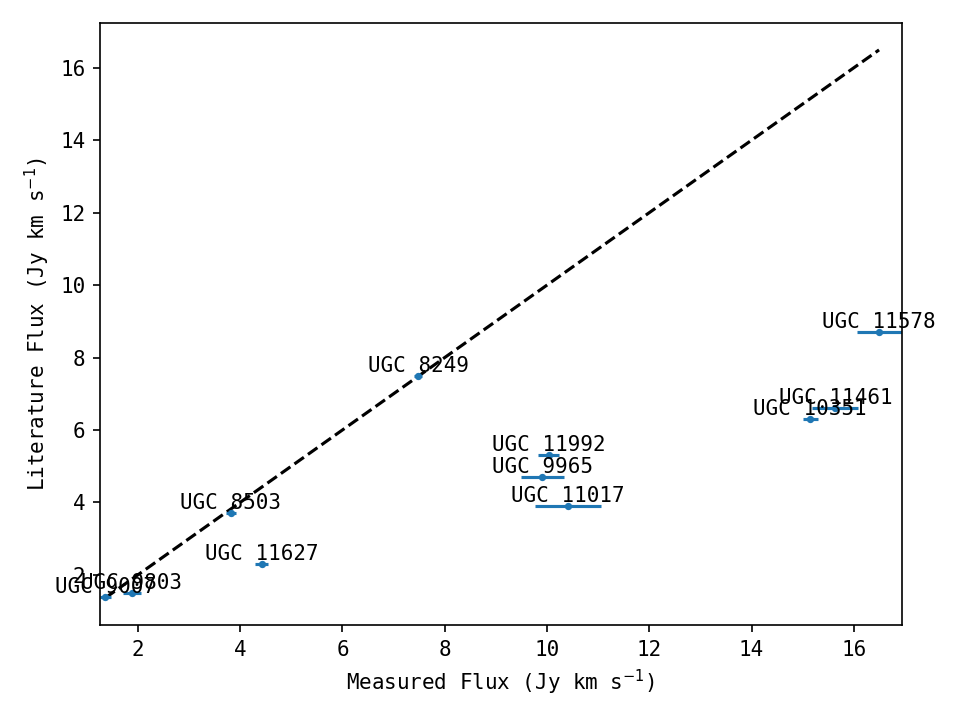

In [71]:
plt.figure(dpi=150)
# Plot a 1-to-1 line using the observed values.
plt.plot(sorted(df_obs_s["flux"]), sorted(df_obs_s["flux"]), "k--")
plt.errorbar(df_obs_s["flux"], df_lit_s["flux"], 
             xerr=df_obs_s["flux_error"], 
             yerr=df_lit_s["flux_error"], 
             marker=".", ls="", ms=5)
for n,o,l in zip(df_obs_s["name"], df_obs_s["flux"], df_lit_s["flux"]):
    plt.text(o, l, n, ha="center", va="bottom")
plt.xlabel("Measured Flux (Jy km s$^{-1}$)")
plt.ylabel("Literature Flux (Jy km s$^{-1}$)")
plt.tight_layout()
plt.show()

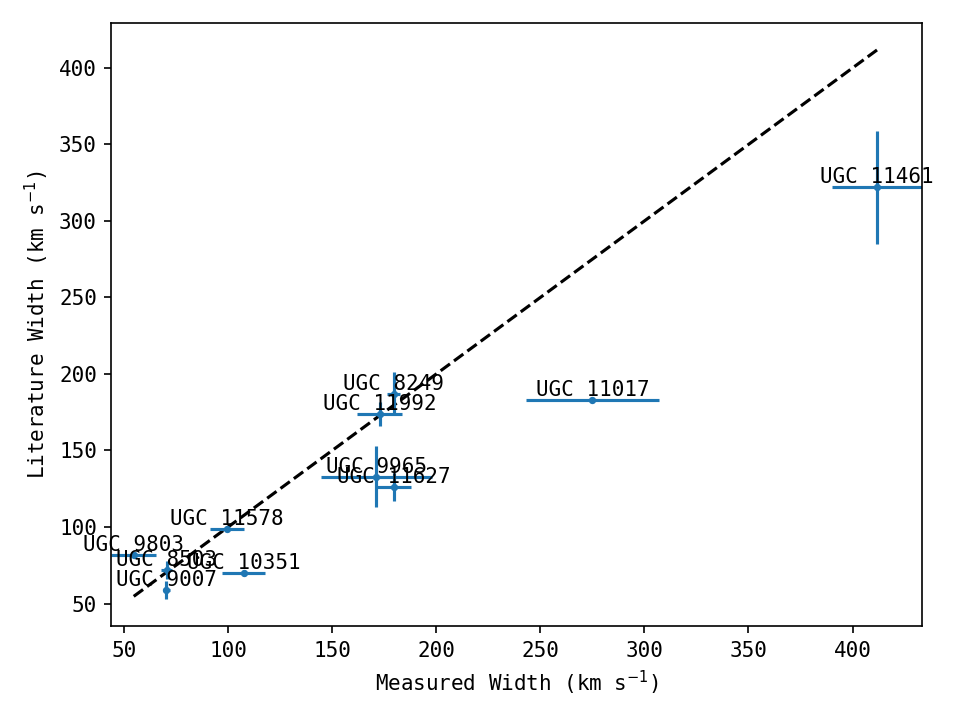

In [72]:
plt.figure(dpi=150)
# Plot a 1-to-1 line using the observed values.
plt.plot(sorted(df_obs_s["width"]), sorted(df_obs_s["width"]), "k--")
plt.errorbar(df_obs_s["width"], df_lit_s["width"], 
             xerr=df_obs_s["width_error"], 
             yerr=df_lit_s["width_error"], 
             marker=".", ls="", ms=5)
for n,o,l in zip(df_obs_s["name"], df_obs_s["width"], df_lit_s["width"]):
    plt.text(o, l, n, ha="center", va="bottom")
plt.xlabel("Measured Width (km s$^{-1}$)")
plt.ylabel("Literature Width (km s$^{-1}$)")
plt.tight_layout()
plt.show()